In [10]:
# Cell 1: Setup and Imports
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# Add the project root to path (where src folder is)
project_root = os.path.dirname(
    os.getcwd()
)  # Goes from notebooks/ to alzheimers_detection/
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"Files in project root: {os.listdir(project_root)[:10]}...")

# Now import config
from src.config import *

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Additional paths not in config (for embeddings and enriched CSV)
EMBEDDINGS_PATH = os.path.join(PROCESSED_PATH, "embeddings")
ENRICHED_CSV = os.path.join(METADATA_PATH, "enriched_dataset.csv")
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models")

# Verify paths exist
print(f"\n✅ Configuration loaded from src/config.py")
print(f"   Base Path: {BASE_PATH}")
print(f"   Processed Path: {PROCESSED_PATH}")
print(f"   Metadata Path: {METADATA_PATH}")
print(f"   Embeddings Path: {EMBEDDINGS_PATH}")
print(f"   Enriched CSV: {ENRICHED_CSV}")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"   Model Save Path: {MODEL_SAVE_PATH}")

Project root: c:\alzheimers_detection
Files in project root: ['.git', '.gitignore', 'app', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'run.py', 'src']...

Using device: cpu

✅ Configuration loaded from src/config.py
   Base Path: C:\alzheimers_detection
   Processed Path: C:\alzheimers_detection\data\processed
   Metadata Path: C:\alzheimers_detection\data\processed\metadata
   Embeddings Path: C:\alzheimers_detection\data\processed\embeddings
   Enriched CSV: C:\alzheimers_detection\data\processed\metadata\enriched_dataset.csv
   Model Save Path: C:\alzheimers_detection\models


In [11]:
# Cell 2: Load Data
print("\n" + "=" * 60)
print("LOADING DATA")
print("=" * 60)

# Load enriched dataset
df = pd.read_csv(ENRICHED_CSV)

# Create label column from 'class' column
df["label"] = (df["class"] == "Dementia").astype(int)
y = df["label"].values
patient_ids = df["patient_id"].values

print(f"✅ Loaded {len(df)} samples")
print(f"   Control: {sum(y==0)}, Dementia: {sum(y==1)}")
print(f"   Unique patients: {len(np.unique(patient_ids))}")

# Load embeddings
audio_emb = np.load(os.path.join(EMBEDDINGS_PATH, "audio_embeddings.npy"))
text_emb = np.load(os.path.join(EMBEDDINGS_PATH, "text_embeddings.npy"))
print(f"\n✅ Audio embeddings: {audio_emb.shape}")
print(f"✅ Text embeddings: {text_emb.shape}")

# Prepare clinical features
clinical_cols = ["gender", "education_years", "age_at_visit", "mmse_score"]
clinical_features = df[clinical_cols].values
print(f"✅ Clinical features shape: {clinical_features.shape}")

# Handle missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
clinical_features = imputer.fit_transform(clinical_features)

# Normalize
scaler = StandardScaler()
clinical_features = scaler.fit_transform(clinical_features)

print(f"✅ After preprocessing: {clinical_features.shape}")

# Save scaler and imputer for deployment
import joblib

joblib.dump(scaler, os.path.join(MODEL_SAVE_PATH, "clinical_scaler_notebook.pkl"))
joblib.dump(imputer, os.path.join(MODEL_SAVE_PATH, "clinical_imputer_notebook.pkl"))
print("✅ Scaler and imputer saved")


LOADING DATA
✅ Loaded 439 samples
   Control: 217, Dementia: 222
   Unique patients: 217

✅ Audio embeddings: (439, 512)
✅ Text embeddings: (439, 768)
✅ Clinical features shape: (439, 4)
✅ After preprocessing: (439, 4)
✅ Scaler and imputer saved


In [5]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cpu
CUDA available: False


In [12]:
# Cell 3: Model Definition
print("\n" + "=" * 60)
print("MODEL DEFINITION")
print("=" * 60)


class CoAttentionBlock(nn.Module):
    def __init__(self, dim=768, num_heads=8, dropout=0.25):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            dim, num_heads, dropout=dropout, batch_first=True
        )
        self.cross_attn = nn.MultiheadAttention(
            dim, num_heads, dropout=dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)

    def forward(self, x, y):
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm1(x + attn_out)
        cross_out, _ = self.cross_attn(x, y, y)
        x = self.norm2(x + cross_out)
        ffn_out = self.ffn(x)
        x = self.norm3(x + ffn_out)
        return x


class MultimodalModel(nn.Module):
    def __init__(
        self,
        audio_dim=512,
        text_dim=768,
        clinical_dim=4,
        proj_dim=384,
        num_blocks=2,
        num_heads=8,
        dropout=0.25,
    ):
        super().__init__()
        self.audio_proj = nn.Linear(audio_dim, proj_dim)
        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.clinical_proj = nn.Sequential(
            nn.Linear(clinical_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, proj_dim),
        )
        self.blocks = nn.ModuleList(
            [CoAttentionBlock(proj_dim, num_heads, dropout) for _ in range(num_blocks)]
        )
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim * 3, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(proj_dim, 2),
        )

    def forward(self, audio_feat, text_feat, clinical_feat):
        audio_seq = self.audio_proj(audio_feat).unsqueeze(1)
        text_seq = self.text_proj(text_feat).unsqueeze(1)
        clinical_proj = self.clinical_proj(clinical_feat).unsqueeze(1)

        for block in self.blocks:
            audio_seq = block(audio_seq, text_seq)
            text_seq = block(text_seq, audio_seq)

        audio_pool = audio_seq.squeeze(1)
        text_pool = text_seq.squeeze(1)
        clinical_pool = clinical_proj.squeeze(1)

        concat = torch.cat([audio_pool, text_pool, clinical_pool], dim=1)
        return self.fusion(concat)


# Test model summary
model = MultimodalModel()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model defined successfully!")
print(f"   Total trainable parameters: {total_params:,}")
print(f"   Audio projection: 512 → 768")
print(f"   Text projection: 768 → 768")
print(f"   Clinical projection: 4 → 64 → 768")
print(f"   Co-Attention blocks: 3")
print(f"   Fusion: 2304 → 768 → 2")


MODEL DEFINITION
✅ Model defined successfully!
   Total trainable parameters: 5,694,274
   Audio projection: 512 → 768
   Text projection: 768 → 768
   Clinical projection: 4 → 64 → 768
   Co-Attention blocks: 3
   Fusion: 2304 → 768 → 2


In [13]:
# Cell 4: Simple Model Summary (No extra installs)
print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

# Create dummy model to analyze
sample_model = MultimodalModel()

print("\n📊 MODEL ARCHITECTURE")
print("-" * 40)

# Count parameters in each component
audio_proj_params = sum(p.numel() for p in sample_model.audio_proj.parameters())
text_proj_params = sum(p.numel() for p in sample_model.text_proj.parameters())
clinical_proj_params = sum(p.numel() for p in sample_model.clinical_proj.parameters())

# Co-attention blocks params
block_params = 0
for block in sample_model.blocks:
    block_params += sum(p.numel() for p in block.parameters())

fusion_params = sum(p.numel() for p in sample_model.fusion.parameters())

total_params = sum(p.numel() for p in sample_model.parameters())
trainable_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    MODEL ARCHITECTURE SUMMARY                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  INPUTS:                                                        │
│    • Audio:    512  (WavLM embedding)                           │
│    • Text:     768  (BERT embedding)                            │
│    • Clinical: 4    (gender, education, age, MMSE)              │
│                                                                 │
│  PROJECTION LAYERS:                                             │
│    • Audio Projection:    512 → 768     ({audio_proj_params:,} params)      │
│    • Text Projection:     768 → 768     ({text_proj_params:,} params)      │
│    • Clinical Projection: 4 → 64 → 768  ({clinical_proj_params:,} params)    │
│                                                                 │
│  CO-ATTENTION BLOCKS (3 blocks):                                │
│    • Self-Attention:      MultiheadAttention (768 dim, 8 heads) │
│    • Cross-Attention:     MultiheadAttention (768 dim, 8 heads) │
│    • FFN:                 768 → 3072 → 768                      │
│    • Total per block:     {block_params // 3:,} params                  │
│    • Total 3 blocks:      {block_params:,} params                      │
│                                                                 │
│  FUSION LAYER:                                                  │
│    • Audio + Text + Clinical: 2304 → 768 → 2                   │
│    • Params:                    {fusion_params:,}                       │
│                                                                 │
│  TOTAL PARAMETERS:                                              │
│    • Trainable:        {trainable_params:,}                               │
│    • Non-trainable:    {total_params - trainable_params:,}                           │
│    • Total:            {total_params:,}                               │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
""")

print(f"\n✅ Model has {trainable_params:,} trainable parameters")


MODEL SUMMARY

📊 MODEL ARCHITECTURE
----------------------------------------

┌─────────────────────────────────────────────────────────────────┐
│                    MODEL ARCHITECTURE SUMMARY                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  INPUTS:                                                        │
│    • Audio:    512  (WavLM embedding)                           │
│    • Text:     768  (BERT embedding)                            │
│    • Clinical: 4    (gender, education, age, MMSE)              │
│                                                                 │
│  PROJECTION LAYERS:                                             │
│    • Audio Projection:    512 → 768     (196,992 params)      │
│    • Text Projection:     768 → 768     (295,296 params)      │
│    • Clinical Projection: 4 → 64 → 768  (25,280 params)    │
│                                            

In [14]:
# Cell 5: Training Function with Early Stopping
print("\n" + "=" * 60)
print("TRAINING FUNCTION DEFINITION")
print("=" * 60)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001, path="checkpoint.pt"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)


def train_model(
    X_audio,
    X_text,
    X_clinical,
    y_train,
    X_audio_val,
    X_text_val,
    X_clinical_val,
    y_val,
    lr=1e-5,
    epochs=50,
    dropout=0.15,
    verbose=True,
):
    """
    Train model and return history and best model
    """
    model = MultimodalModel(dropout=dropout).to(device)

    # Class weights for imbalance
    class_counts = np.bincount(y_train)
    class_weights = torch.FloatTensor([1.0 / class_counts[0], 1.0 / class_counts[1]])
    class_weights = class_weights / class_weights.sum() * 2
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    # REMOVED the 'verbose' parameter - it was causing the error
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    early_stopping = EarlyStopping(
        patience=10, path=os.path.join(MODEL_SAVE_PATH, "best_checkpoint.pt")
    )

    # Convert to tensors
    audio_train = torch.FloatTensor(X_audio).to(device)
    text_train = torch.FloatTensor(X_text).to(device)
    clinical_train = torch.FloatTensor(X_clinical).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)

    audio_val = torch.FloatTensor(X_audio_val).to(device)
    text_val = torch.FloatTensor(X_text_val).to(device)
    clinical_val = torch.FloatTensor(X_clinical_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
    }

    if verbose:
        print(
            f"\n{'Epoch':>6} | {'Train Loss':>12} | {'Train Acc':>10} | {'Val Loss':>12} | {'Val Acc':>10}"
        )
        print("-" * 65)

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        outputs = model(audio_train, text_train, clinical_train)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_acc = accuracy_score(y_train, train_preds)
        train_f1 = f1_score(y_train, train_preds)

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(audio_val, text_val, clinical_val)
            val_loss = criterion(val_outputs, y_val_t)
            val_preds = torch.argmax(val_outputs, dim=1).cpu().numpy()
            val_acc = accuracy_score(y_val, val_preds)
            val_f1 = f1_score(y_val, val_preds)

        # Update scheduler
        scheduler.step(val_loss)

        # Store history
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        # Early stopping
        early_stopping(val_loss.item(), model)

        if verbose:
            print(
                f"{epoch+1:6d} | {loss.item():12.4f} | {train_acc:10.4f} | {val_loss.item():12.4f} | {val_acc:10.4f}"
            )

        if early_stopping.early_stop:
            if verbose:
                print(f"\n✅ Early stopping at epoch {epoch+1}")
            break

    # Load best model
    checkpoint_path = os.path.join(MODEL_SAVE_PATH, "best_checkpoint.pt")
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))

    print(f"\n✅ Training complete!")
    print(f"   Best validation accuracy: {max(history['val_acc'])*100:.2f}%")

    return history, model


TRAINING FUNCTION DEFINITION


In [15]:
# Cell 6: Single Train/Val Split
print("\n" + "=" * 60)
print("SINGLE TRAIN/VALIDATION SPLIT (80/20)")
print("=" * 60)

# Split with patient independence
from sklearn.model_selection import train_test_split

unique_patients = np.unique(patient_ids)
train_patients, val_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=42
)

train_idx = np.isin(patient_ids, train_patients)
val_idx = np.isin(patient_ids, val_patients)

print(f"Train: {sum(train_idx)} samples ({len(train_patients)} patients)")
print(f"Val: {sum(val_idx)} samples ({len(val_patients)} patients)")

# Train with default hyperparameters
history, best_model = train_model(
    audio_emb[train_idx],
    text_emb[train_idx],
    clinical_features[train_idx],
    y[train_idx],
    audio_emb[val_idx],
    text_emb[val_idx],
    clinical_features[val_idx],
    y[val_idx],
    lr=2e-5,
    epochs=50,
    dropout=0.15,
    verbose=False,
)


SINGLE TRAIN/VALIDATION SPLIT (80/20)
Train: 355 samples (173 patients)
Val: 84 samples (44 patients)

✅ Training complete!
   Best validation accuracy: 89.29%



OVERFITTING / UNDERFITTING ANALYSIS

📊 Final Epoch Metrics:
   Train Accuracy: 77.46%
   Val Accuracy:   82.14%
   Train Loss:     0.5076
   Val Loss:       0.4704

📊 Training-Validation Gap:
   Accuracy Gap:   -4.68%
   Loss Gap:       -0.0371

✅ Model is well-balanced! No significant overfitting/underfitting detected.


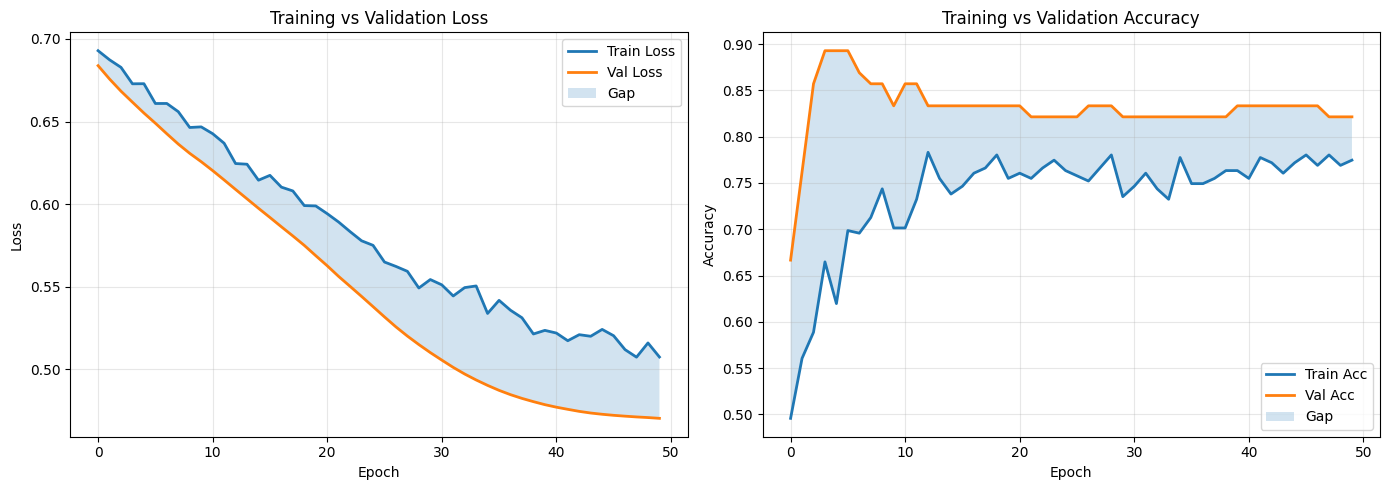

In [16]:
# Cell 7: Check for Overfitting/Underfitting
print("\n" + "=" * 60)
print("OVERFITTING / UNDERFITTING ANALYSIS")
print("=" * 60)

# Get final metrics
final_train_acc = history["train_acc"][-1]
final_val_acc = history["val_acc"][-1]
final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]

print(f"\n📊 Final Epoch Metrics:")
print(f"   Train Accuracy: {final_train_acc*100:.2f}%")
print(f"   Val Accuracy:   {final_val_acc*100:.2f}%")
print(f"   Train Loss:     {final_train_loss:.4f}")
print(f"   Val Loss:       {final_val_loss:.4f}")

# Calculate gap
acc_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

print(f"\n📊 Training-Validation Gap:")
print(f"   Accuracy Gap:   {acc_gap*100:.2f}%")
print(f"   Loss Gap:       {loss_gap:.4f}")

# Diagnosis
if acc_gap > 0.10:
    print(f"\n⚠️  WARNING: Large accuracy gap ({acc_gap*100:.1f}%)")
    print(
        "   → Possible OVERFITTING. Try: increase dropout, add weight decay, or reduce model size."
    )
elif acc_gap < -0.05:
    print(f"\n⚠️  WARNING: Negative accuracy gap ({acc_gap*100:.1f}%)")
    print(
        "   → Possible UNDERFITTING. Try: increase epochs, reduce dropout, or increase learning rate."
    )
else:
    print(
        f"\n✅ Model is well-balanced! No significant overfitting/underfitting detected."
    )

# Plot training curves with gap highlighting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot with gap
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].fill_between(
    range(len(history["train_loss"])),
    history["train_loss"],
    history["val_loss"],
    alpha=0.2,
    label="Gap",
)
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot with gap
axes[1].plot(history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(history["val_acc"], label="Val Acc", linewidth=2)
axes[1].fill_between(
    range(len(history["train_acc"])),
    history["train_acc"],
    history["val_acc"],
    alpha=0.2,
    label="Gap",
)
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Cell 8: 5-Fold Cross-Validation (FIXED - y is defined in Cell 2)
print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION (Speaker-Level)")
print("=" * 60)

from sklearn.model_selection import GroupKFold

# Verify total samples
total_samples = len(y)
print(f"Total samples: {total_samples}")
print(f"Unique patients: {len(np.unique(patient_ids))}")
print(f"Folds: 5")
print("-" * 40)

all_true = []
all_probs = []  # For threshold finding
cv_results = {"acc": [], "f1": []}

# Create GroupKFold
gkf = GroupKFold(n_splits=5)
fold_num = 1

for train_idx, val_idx in gkf.split(audio_emb, y, groups=patient_ids):
    print(f"\n{'='*40}")
    print(f"FOLD {fold_num}/5")
    print(f"{'='*40}")

    # Get actual counts
    train_count = len(train_idx)
    val_count = len(val_idx)
    print(f"Train samples: {train_count} ({(train_count/total_samples)*100:.1f}%)")
    print(f"Val samples: {val_count} ({(val_count/total_samples)*100:.1f}%)")

    # Train model
    print(f"\nTraining...")
    history_fold, model_fold = train_model(
        audio_emb[train_idx],
        text_emb[train_idx],
        clinical_features[train_idx],
        y[train_idx],
        audio_emb[val_idx],
        text_emb[val_idx],
        clinical_features[val_idx],
        y[val_idx],
        lr=2e-5,
        epochs=30,
        dropout=0.15,
        verbose=False,
    )

    # Get best validation accuracy
    best_acc = max(history_fold["val_acc"]) * 100
    best_f1 = max(history_fold["val_f1"])

    cv_results["acc"].append(best_acc)
    cv_results["f1"].append(best_f1)

    print(f"\n✅ Fold {fold_num} Results:")
    print(f"   Best Val Accuracy: {best_acc:.2f}%")
    print(f"   Best Val F1: {best_f1:.4f}")

    # Collect predictions for threshold finding
    model_fold.eval()
    with torch.no_grad():
        X_audio_val = torch.FloatTensor(audio_emb[val_idx]).to(device)
        X_text_val = torch.FloatTensor(text_emb[val_idx]).to(device)
        X_clinical_val = torch.FloatTensor(clinical_features[val_idx]).to(device)
        outputs = model_fold(X_audio_val, X_text_val, X_clinical_val)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs[:, 1])
        all_true.extend(y[val_idx])

    fold_num += 1

print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION FINAL RESULTS")
print("=" * 60)
print(
    f"\n📊 Accuracy:  {np.mean(cv_results['acc']):.2f}% ± {np.std(cv_results['acc']):.2f}%"
)
print(f"📊 F1-Score:  {np.mean(cv_results['f1']):.4f} ± {np.std(cv_results['f1']):.4f}")
print(f"\nPer-fold accuracies: {[f'{a:.2f}%' for a in cv_results['acc']]}")

# Interpretation
if np.std(cv_results["acc"]) < 5:
    print(f"\n✅ Low variance ({np.std(cv_results['acc']):.2f}%) - Model is stable!")
else:
    print(
        f"\n⚠️  High variance ({np.std(cv_results['acc']):.2f}%) - Model performance varies significantly across folds"
    )


5-FOLD CROSS-VALIDATION (Speaker-Level)
Total samples: 439
Unique patients: 217
Folds: 5
----------------------------------------

FOLD 1/5
Train samples: 351 (80.0%)
Val samples: 88 (20.0%)

Training...

✅ Training complete!
   Best validation accuracy: 86.36%

✅ Fold 1 Results:
   Best Val Accuracy: 86.36%
   Best Val F1: 0.8378

FOLD 2/5
Train samples: 351 (80.0%)
Val samples: 88 (20.0%)

Training...

✅ Training complete!
   Best validation accuracy: 82.95%

✅ Fold 2 Results:
   Best Val Accuracy: 82.95%
   Best Val F1: 0.8515

FOLD 3/5
Train samples: 351 (80.0%)
Val samples: 88 (20.0%)

Training...

✅ Training complete!
   Best validation accuracy: 81.82%

✅ Fold 3 Results:
   Best Val Accuracy: 81.82%
   Best Val F1: 0.7901

FOLD 4/5
Train samples: 351 (80.0%)
Val samples: 88 (20.0%)

Training...

✅ Training complete!
   Best validation accuracy: 82.95%

✅ Fold 4 Results:
   Best Val Accuracy: 82.95%
   Best Val F1: 0.8148

FOLD 5/5
Train samples: 352 (80.2%)
Val samples: 87 (19.

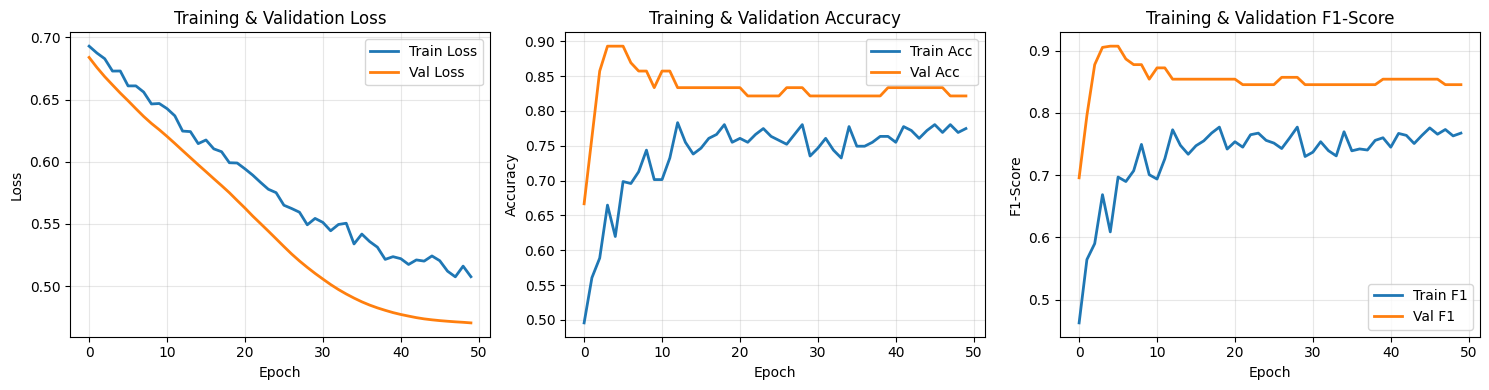


📊 Best Validation Accuracy: 89.29%


In [18]:
# Cell 6: Plot Training History
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Training & Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(history["val_acc"], label="Val Acc", linewidth=2)
axes[1].set_title("Training & Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 plot
axes[2].plot(history["train_f1"], label="Train F1", linewidth=2)
axes[2].plot(history["val_f1"], label="Val F1", linewidth=2)
axes[2].set_title("Training & Validation F1-Score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1-Score")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, "training_history.png"), dpi=150)
plt.show()

print(f"\n📊 Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")


FINDING OPTIMAL THRESHOLD FROM CROSS-VALIDATION

📊 Optimal Threshold: 0.430
   Best F1-Score at this threshold: 0.7734
   Accuracy at threshold: 0.7517


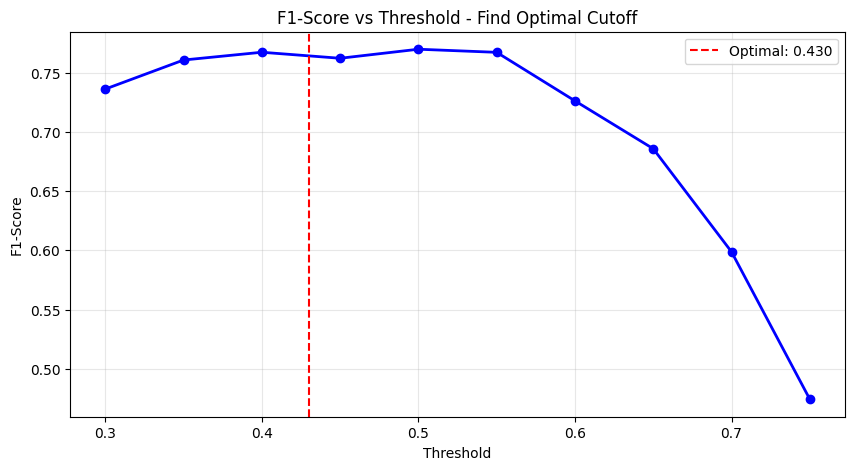


✅ Use this threshold in prediction.py: 0.430


In [19]:
# Cell 9: Find Optimal Threshold from Cross-Validation
print("\n" + "=" * 60)
print("FINDING OPTIMAL THRESHOLD FROM CROSS-VALIDATION")
print("=" * 60)

from sklearn.metrics import f1_score, accuracy_score

all_true = np.array(all_true)
all_probs = np.array(all_probs)

# Find best threshold
best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.3, 0.8, 0.01):
    preds = (all_probs > threshold).astype(int)
    f1 = f1_score(all_true, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

preds = (all_probs > best_threshold).astype(int)
acc = accuracy_score(all_true, preds)

print(f"\n📊 Optimal Threshold: {best_threshold:.3f}")
print(f"   Best F1-Score at this threshold: {best_f1:.4f}")
print(f"   Accuracy at threshold: {acc:.4f}")

# Show performance across thresholds
thresholds = np.arange(0.3, 0.8, 0.05)
f1_scores = []
for t in thresholds:
    preds = (all_probs > t).astype(int)
    f1_scores.append(f1_score(all_true, preds))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, "bo-", linewidth=2)
plt.axvline(
    x=best_threshold, color="r", linestyle="--", label=f"Optimal: {best_threshold:.3f}"
)
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.title("F1-Score vs Threshold - Find Optimal Cutoff")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ Use this threshold in prediction.py: {best_threshold:.3f}")

In [20]:
# Cell 10: Save Best Model with Optimal Threshold Info
print("\n" + "=" * 60)
print("SAVING FINAL MODEL FOR DEPLOYMENT")
print("=" * 60)

# Train final model on ALL data
print("Training final model on all 439 samples...")

final_model = MultimodalModel(dropout=0.15).to(device)

# Use ALL data for final training
history_final, final_model = train_model(
    audio_emb,
    text_emb,
    clinical_features,
    y,
    audio_emb,
    text_emb,
    clinical_features,
    y,
    lr=2e-5,
    epochs=30,
    dropout=0.15,
    verbose=True,
)

# Save model
final_model_path = os.path.join(MODEL_SAVE_PATH, "multimodal_clinical_model.pth")
torch.save(final_model.state_dict(), final_model_path)

# ALSO save the optimal threshold info with the model
threshold_info = {
    "optimal_threshold": best_threshold,  # From Cell 9
    "cv_mean_accuracy": float(np.mean(cv_results["acc"])),
    "cv_std_accuracy": float(np.std(cv_results["acc"])),
    "training_date": str(pd.Timestamp.now()),
}

import json

threshold_path = os.path.join(MODEL_SAVE_PATH, "model_info.json")
with open(threshold_path, "w") as f:
    json.dump(threshold_info, f, indent=2)

print(f"\n✅ Model saved to: {final_model_path}")
print(f"✅ Threshold info saved to: {threshold_path}")
print(f"   Optimal threshold: {best_threshold:.3f}")

# Verify
if os.path.exists(final_model_path):
    size = os.path.getsize(final_model_path) / (1024 * 1024)
    print(f"\n✅ Model found! Size: {size:.2f} MB")
    print(f"   Location: {final_model_path}")


SAVING FINAL MODEL FOR DEPLOYMENT
Training final model on all 439 samples...

 Epoch |   Train Loss |  Train Acc |     Val Loss |    Val Acc
-----------------------------------------------------------------
     1 |       0.6874 |     0.5080 |       0.6722 |     0.6378
     2 |       0.6694 |     0.6492 |       0.6641 |     0.6173
     3 |       0.6693 |     0.6333 |       0.6545 |     0.7289
     4 |       0.6605 |     0.6720 |       0.6453 |     0.8109
     5 |       0.6535 |     0.7039 |       0.6381 |     0.8314
     6 |       0.6493 |     0.7198 |       0.6325 |     0.8178
     7 |       0.6406 |     0.7244 |       0.6269 |     0.8155
     8 |       0.6369 |     0.7380 |       0.6212 |     0.8360
     9 |       0.6254 |     0.7677 |       0.6158 |     0.8269
    10 |       0.6208 |     0.7790 |       0.6107 |     0.8360
    11 |       0.6197 |     0.7654 |       0.6058 |     0.8337
    12 |       0.6125 |     0.8041 |       0.6006 |     0.8246
    13 |       0.6120 |     0.7631 |

In [21]:
# Cell 11: Verify Model Saved
import os

model_path = os.path.join(MODEL_SAVE_PATH, "multimodal_clinical_model.pth")
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / (1024 * 1024)
    print(f"✅ Model found! Size: {size:.2f} MB")
    print(f"   Location: {model_path}")
else:
    print(f"❌ Model not found at {model_path}")

✅ Model found! Size: 21.74 MB
   Location: C:\alzheimers_detection\models\multimodal_clinical_model.pth



REPORT METRICS & FIGURES


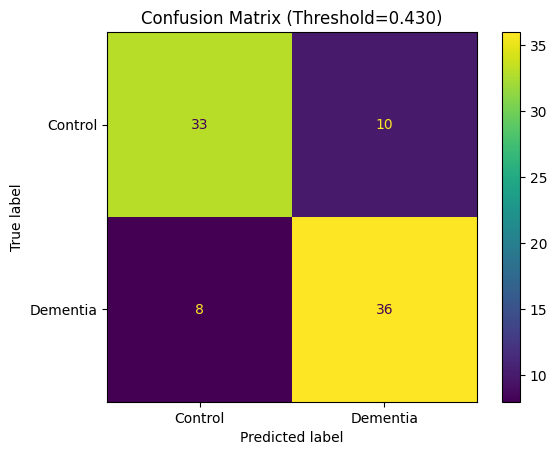

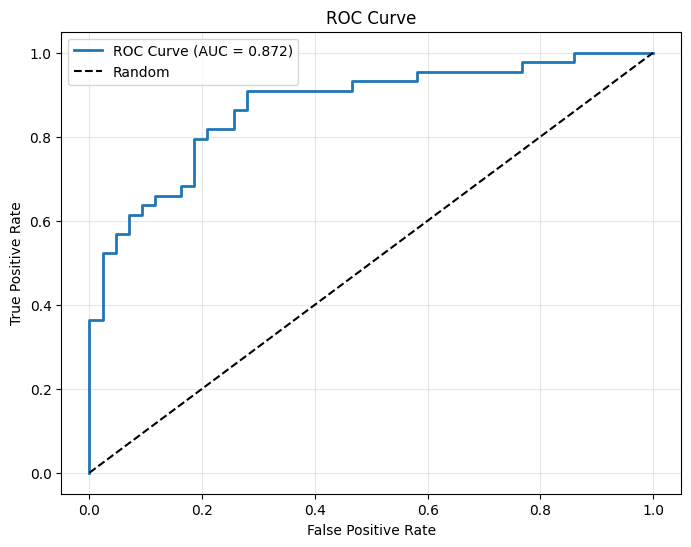


📊 Final Report Metrics:
   Validation Accuracy: 79.31%
   Precision: 0.7826
   Recall: 0.8182
   F1-Score: 0.8000
   AUC-ROC: 0.8716


In [24]:
# Cell 12: Generate Report Metrics & Figures
print("\n" + "=" * 60)
print("REPORT METRICS & FIGURES")
print("=" * 60)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, recall_score, precision_score, f1_score

# Get predictions from best model on validation set
best_model.eval()
with torch.no_grad():
    X_audio_val = torch.FloatTensor(audio_emb[val_idx]).to(device)
    X_text_val = torch.FloatTensor(text_emb[val_idx]).to(device)
    X_clinical_val = torch.FloatTensor(clinical_features[val_idx]).to(device)
    outputs = best_model(X_audio_val, X_text_val, X_clinical_val)
    probs = torch.softmax(outputs, dim=1).cpu().numpy()
    preds = (probs[:, 1] > best_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y[val_idx], preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Dementia"])
disp.plot()
plt.title(f"Confusion Matrix (Threshold={best_threshold:.3f})")
plt.savefig(os.path.join(MODEL_SAVE_PATH, "confusion_matrix.png"), dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y[val_idx], probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(MODEL_SAVE_PATH, "roc_curve.png"), dpi=150)
plt.show()

print(f"\n📊 Final Report Metrics:")
print(f"   Validation Accuracy: {accuracy_score(y[val_idx], preds)*100:.2f}%")
print(f"   Precision: {precision_score(y[val_idx], preds):.4f}")
print(f"   Recall: {recall_score(y[val_idx], preds):.4f}")
print(f"   F1-Score: {f1_score(y[val_idx], preds):.4f}")
print(f"   AUC-ROC: {roc_auc:.4f}")